In [4]:
from dieslog import DiesLog
import numpy as np
import matplotlib.pyplot as plt

logfile = '../logs/dies-2026-06-21_13-52-56'
l = DiesLog(logfile)

<Axes: xlabel='t [s]', ylabel='speed [mm/s]'>

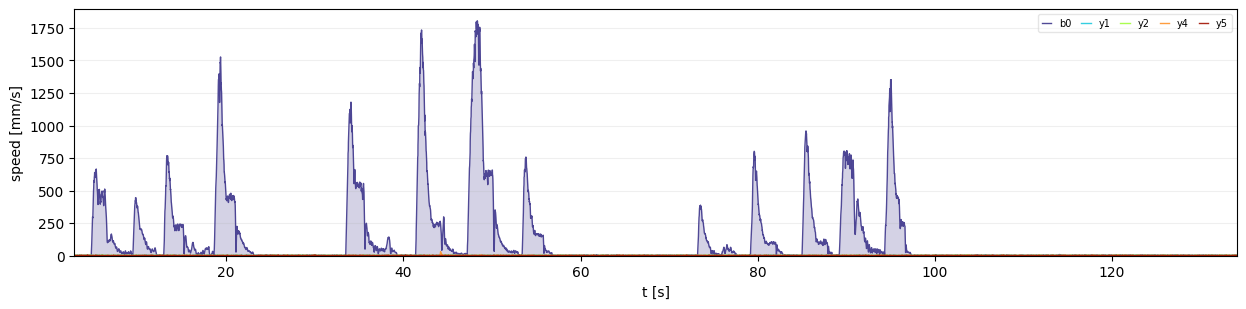

In [5]:
l.timeline()

In [7]:
l.robots()

[('blue', 0), ('yellow', 1), ('yellow', 2), ('yellow', 4), ('yellow', 5)]

<Figure size 1500x320 with 0 Axes>

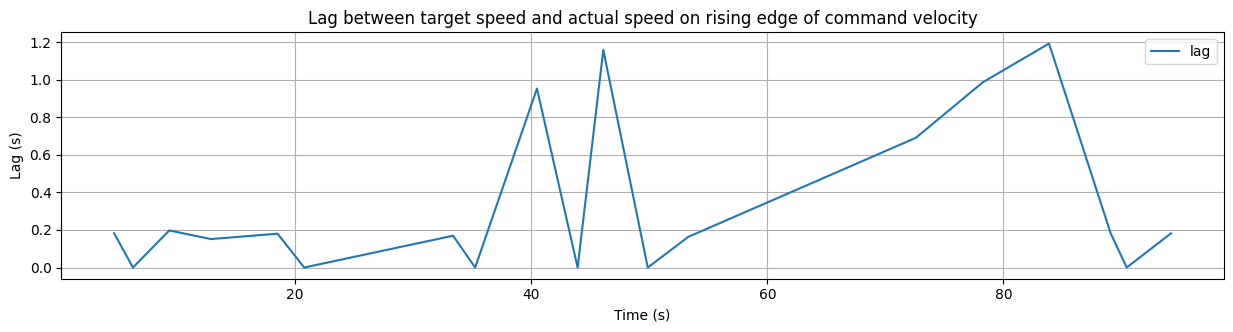

In [14]:
r0 = l.robot('blue', 0)
plt.figure(figsize=(15, 3.2))

# plt.plot(r0.index, np.hypot(r0.vx, r0.vy), label='speed')
# plt.plot(r0.index, np.hypot(r0.target_vel_x, r0.target_vel_y), label='target speed')
# plt.legend()
# plt.title('Robot 0 speed vs target speed')
# plt.xlabel('Time (s)')
# plt.ylabel('Speed (mm/s)')
# plt.grid()
# plt.show()

target_speed_threshold = 100
target_speed = np.hypot(
    r0.target_vel_x.to_numpy(dtype=float),
    r0.target_vel_y.to_numpy(dtype=float),
)
actual_speed = np.hypot(r0.vx.to_numpy(), r0.vy.to_numpy())
times = r0.index.to_numpy()

events = []
for i in range(1, len(target_speed)):
    if target_speed[i - 1] < target_speed_threshold and target_speed[i] >= target_speed_threshold:
        events.append(i)

lags = []
for event in events:
    post = actual_speed[event:]
    if not np.any(post >= target_speed_threshold):
        continue
    idx = np.argmax(post >= target_speed_threshold)
    lag = times[event + idx] - times[event]
    lags.append(lag)

plt.figure(figsize=(15, 3.2))
plt.plot(times[events[:len(lags)]], lags, label='lag')
plt.legend()
plt.title('Lag between target speed and actual speed on rising edge of command velocity')
plt.xlabel('Time (s)')
plt.ylabel('Lag (s)')
plt.grid()

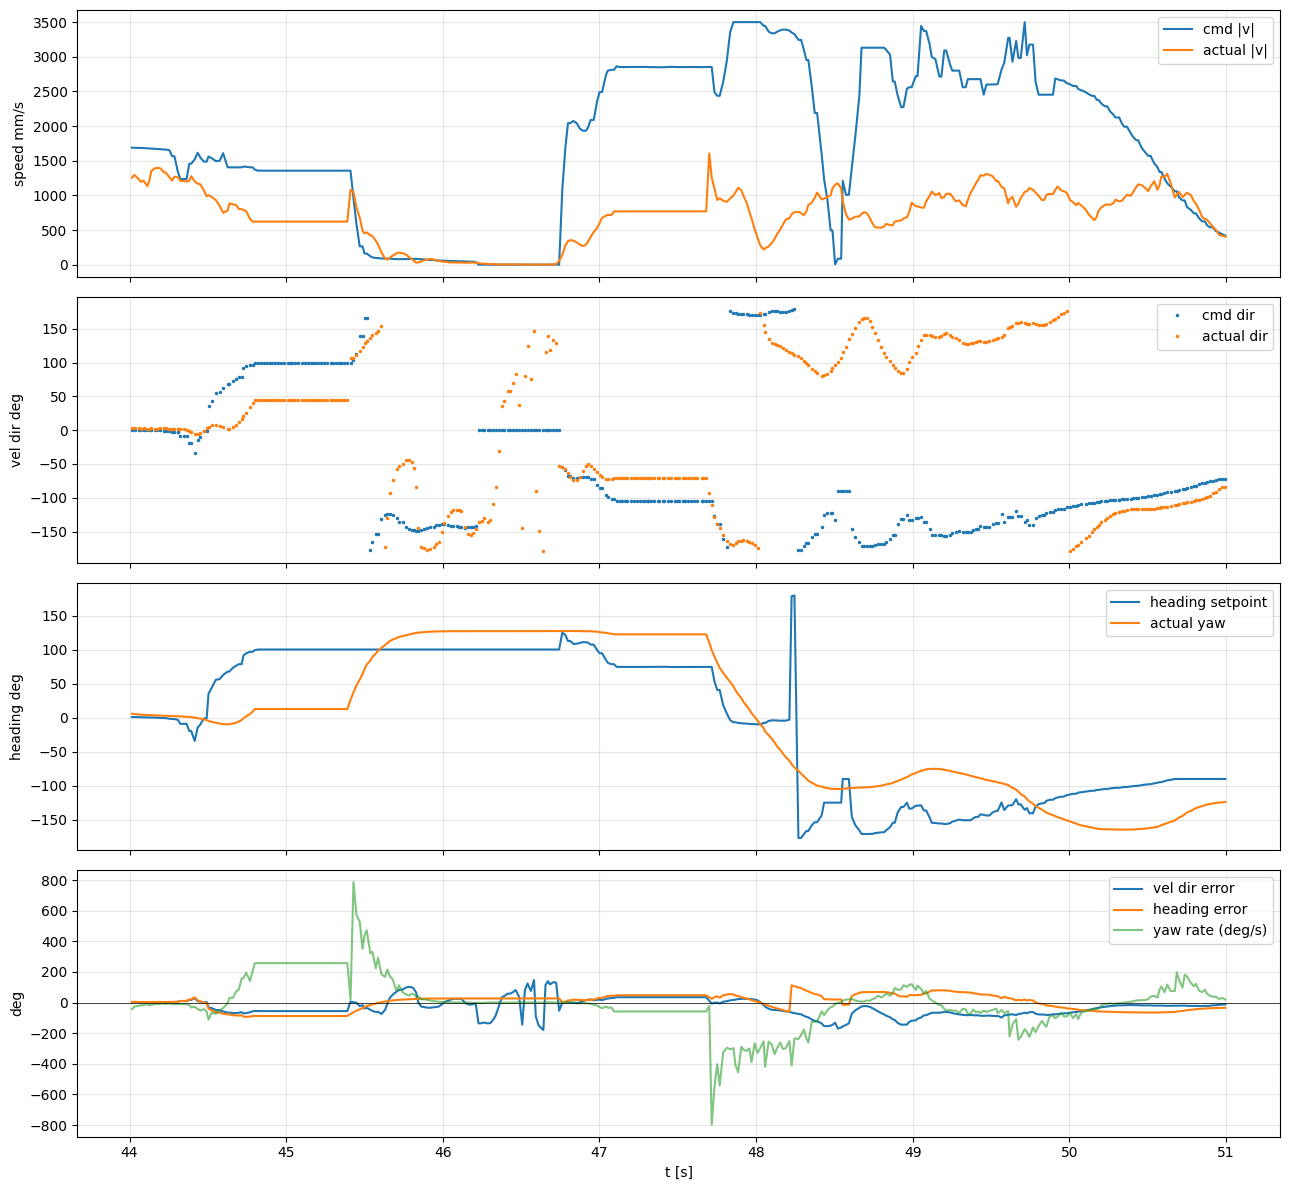

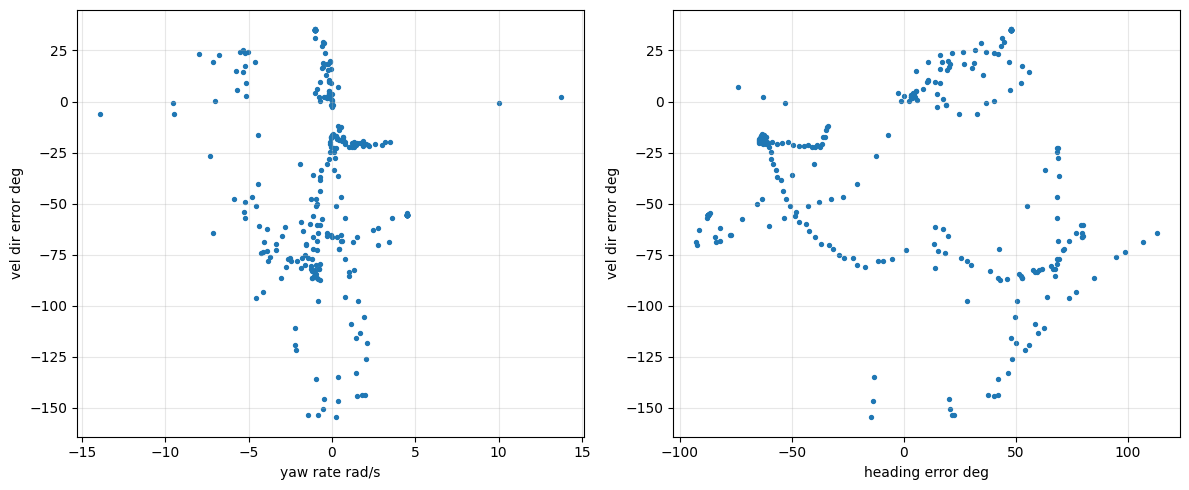

dir_err = -0.046*omega + -0.020*head_err + -0.624 rad
mean |dir_err| 46.8 deg  speed ratio 0.39


In [16]:
from dieslog import load
import numpy as np, matplotlib.pyplot as plt

log = load('../logs/dies-2026-06-21_14-07-23.dieslog')
r = log.robot('blue', 0).loc[44:51].copy()
r['heading_setpoint'] = r['heading_setpoint'].ffill()

wrap = lambda a: (a + np.pi) % (2*np.pi) - np.pi
r['cmd_spd'] = np.hypot(r.target_vel_x, r.target_vel_y)
r['act_spd'] = np.hypot(r.vx, r.vy)
r['cmd_dir'] = np.arctan2(r.target_vel_y, r.target_vel_x)
r['act_dir'] = np.arctan2(r.vy, r.vx)
r['dir_err'] = wrap(r.act_dir - r.cmd_dir)
r['head_err'] = wrap(r.yaw - r.heading_setpoint)

fig, ax = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

ax[0].plot(r.index, r.cmd_spd, label='cmd |v|')
ax[0].plot(r.index, r.act_spd, label='actual |v|')
ax[0].set_ylabel('speed mm/s'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(r.index, np.degrees(r.cmd_dir), '.', ms=3, label='cmd dir')
ax[1].plot(r.index, np.degrees(r.act_dir), '.', ms=3, label='actual dir')
ax[1].set_ylabel('vel dir deg'); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(r.index, np.degrees(r.heading_setpoint), label='heading setpoint')
ax[2].plot(r.index, np.degrees(r.yaw), label='actual yaw')
ax[2].set_ylabel('heading deg'); ax[2].legend(); ax[2].grid(alpha=.3)

ax[3].plot(r.index, np.degrees(r.dir_err), label='vel dir error')
ax[3].plot(r.index, np.degrees(r.head_err), label='heading error')
ax[3].plot(r.index, np.degrees(r.angular_speed), label='yaw rate (deg/s)', alpha=.6)
ax[3].axhline(0, color='k', lw=.5); ax[3].set_ylabel('deg'); ax[3].set_xlabel('t [s]')
ax[3].legend(); ax[3].grid(alpha=.3)
plt.tight_layout(); plt.show()

m = r.dropna(subset=['dir_err', 'angular_speed', 'head_err'])
m = m[m.cmd_spd > 300]
fig2, bx = plt.subplots(1, 2, figsize=(12, 5))
bx[0].scatter(m.angular_speed, np.degrees(m.dir_err), s=8)
bx[0].set_xlabel('yaw rate rad/s'); bx[0].set_ylabel('vel dir error deg'); bx[0].grid(alpha=.3)
bx[1].scatter(np.degrees(m.head_err), np.degrees(m.dir_err), s=8)
bx[1].set_xlabel('heading error deg'); bx[1].set_ylabel('vel dir error deg');
bx[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

X = np.c_[m.angular_speed, m.head_err, np.ones(len(m))]
c, *_ = np.linalg.lstsq(X, m.dir_err, rcond=None)
print('dir_err = %.3f*omega + %.3f*head_err + %.3f rad' % tuple(c))
print('mean |dir_err| %.1f deg  speed ratio %.2f' % (np.degrees(m.dir_err.abs().mean()),
(m.act_spd/m.cmd_spd).median()))